# Powder XRD Workflows

This notebook demonstrates the current PyTex powder XRD surface from `Phase`
construction through reflection generation, broadened spectrum construction, and
plotting. The main teaching case now uses the pinned `ni_fcc` fixture that also
anchors the external-baseline validation artifacts.


In [1]:
from pathlib import Path
import tempfile

import numpy as np

from pytex import (
    AcquisitionGeometry,
    AtomicSite,
    BenchmarkManifest,
    build_crystal_scene,
    CalibrationRecord,
    CrystalCellOverlay,
    CrystalDirection,
    CrystalDirectionOverlay,
    CrystalMap,
    CrystalPlane,
    CrystalPlaneOverlay,
    DirectionAnnotationStyle,
    DiffractionGeometry,
    EulerSet,
    ExperimentManifest,
    FrameDomain,
    FrameTransform,
    Handedness,
    InversePoleFigure,
    KernelSpec,
    KinematicSimulation,
    Lattice,
    get_phase_fixture,
    list_phase_fixtures,
    list_style_themes,
    MeasurementQuality,
    MillerIndex,
    ODF,
    Orientation,
    OrientationRelationship,
    OrientationSet,
    Phase,
    PhaseTransformationRecord,
    PoleFigure,
    PowderPattern,
    PowderReflection,
    ReferenceFrame,
    read_validation_manifest,
    read_workflow_result_manifest,
    resolve_style,
    RadiationSpec,
    Rotation,
    ScatteringSetup,
    SymmetrySpec,
    TransformationVariant,
    UnitCell,
    ValidationManifest,
    VectorSet,
    WorkflowResultManifest,
    ZoneAxis,
    PlaneAnnotationStyle,
    generate_saed_pattern,
    generate_xrd_pattern,
    normalize_ebsd,
    plot_odf,
    plot_crystal_structure_3d,
    plot_inverse_pole_figure,
    plot_ipf_map,
    plot_orientations,
    plot_kam_map,
    plot_pole_figure,
    plot_saed_pattern,
    plot_symmetry_elements,
    plot_symmetry_orbit,
    plot_vector_set,
    plot_xrd_pattern,
)


def make_crystal_frame():
    return ReferenceFrame(
        "crystal",
        FrameDomain.CRYSTAL,
        ("a", "b", "c"),
        Handedness.RIGHT,
    )


def make_context():
    crystal = make_crystal_frame()
    specimen = ReferenceFrame(
        "specimen",
        FrameDomain.SPECIMEN,
        ("x", "y", "z"),
        Handedness.RIGHT,
    )
    map_frame = ReferenceFrame(
        "map",
        FrameDomain.MAP,
        ("i", "j", "k"),
        Handedness.RIGHT,
    )
    detector = ReferenceFrame(
        "detector",
        FrameDomain.DETECTOR,
        ("u", "v", "n"),
        Handedness.RIGHT,
    )
    lab = ReferenceFrame(
        "lab",
        FrameDomain.LABORATORY,
        ("X", "Y", "Z"),
        Handedness.RIGHT,
    )
    phase = get_phase_fixture("ni_fcc").load_phase(crystal_frame=crystal)
    return crystal, specimen, map_frame, detector, lab, phase


def describe_phase_fixture(fixture_id):
    record = get_phase_fixture(fixture_id)
    return {
        "fixture_id": record.fixture_id,
        "display_name": record.display_name,
        "artifact_path": str(record.artifact_path),
        "metadata_path": str(record.metadata_path),
        "intended_uses": tuple(record.metadata["intended_uses"]),
    }


def load_zr_hcp_phase():
    return get_phase_fixture("zr_hcp").load_phase(crystal_frame=make_crystal_frame())


def load_diamond_phase():
    return get_phase_fixture("diamond").load_phase(crystal_frame=make_crystal_frame())


def publication_crystal_style():
    return {
        "crystal": {
            "atom_radius_scale": 0.5,
            "atom_edgewidth": 0.0,
            "atom_surface_resolution": 34,
            "bond_surface_resolution": 28,
            "bond_alpha": 0.72,
            "bond_color": "#7c8ea3",
            "atom_specular_strength": 0.42,
            "light_specular": 0.4,
        }
    }


In [2]:
crystal, specimen, map_frame, detector, lab, phase = make_context()
reference_fixture = describe_phase_fixture("ni_fcc")

pattern = generate_xrd_pattern(
    phase,
    radiation=RadiationSpec.cu_ka(),
    two_theta_range_deg=(20.0, 120.0),
    resolution_deg=0.02,
    max_index=6,
    broadening_fwhm_deg=0.16,
)

print("Fixture:", reference_fixture["display_name"])
print(pattern.radiation)
print("reflections:", len(pattern.reflections))
print("first peak:", pattern.reflections[0])


Fixture: Nickel (FCC)
RadiationSpec(name='Cu Ka', wavelength_angstrom=1.5406, kalpha2_wavelength_angstrom=None, kalpha2_relative_intensity=0.5, anode='Cu', kind='xray')
reflections: 5
first peak: PowderReflection(miller_indices=array([1, 1, 1]), d_spacing_angstrom=2.0345072930892467, two_theta_deg=44.496143415959885, intensity=1141177.328911026, structure_factor_amplitude=112.0, multiplicity=8, structure_factor_real=112.0, structure_factor_imag=-2.0574066225675533e-14, lorentz_polarization_factor=11.371744747598713, intensity_model='xray_atomic_number')


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pymatgen/io/cif.py:720: UserWarning: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _symmetry_space_group_name_H-M used.
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pymatgen/io/cif.py:1224: UserWarning: Issues encountered while parsing CIF: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _symmetry_space_group_name_H-M used.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


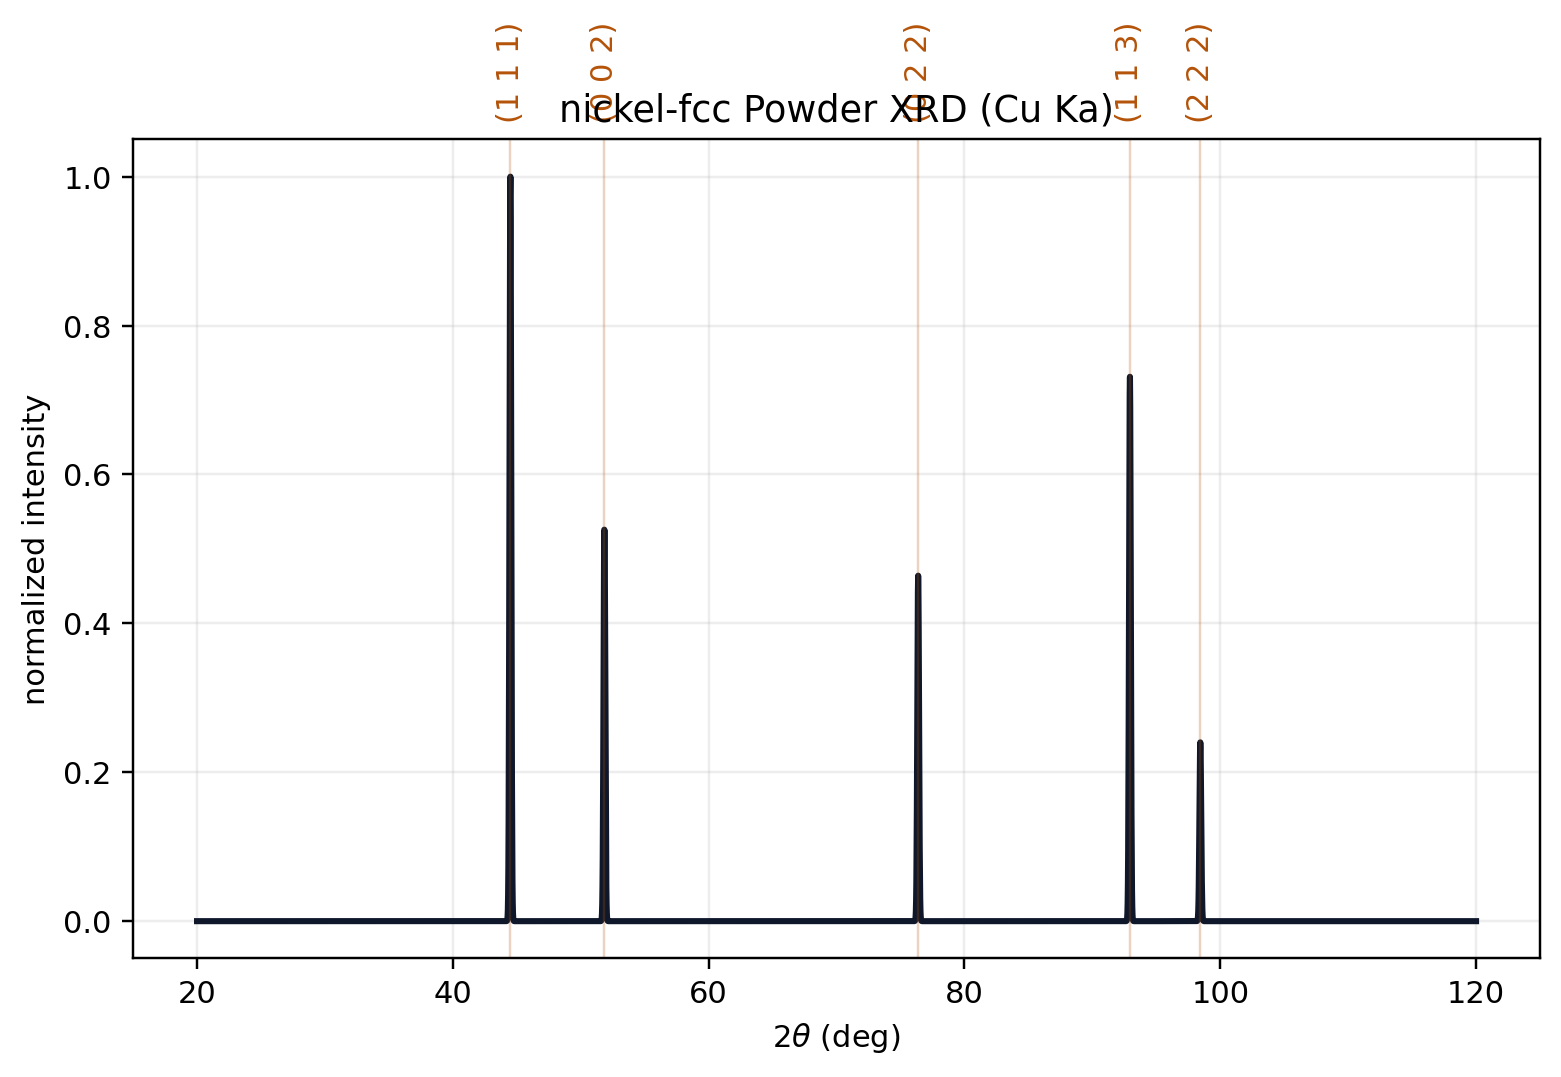

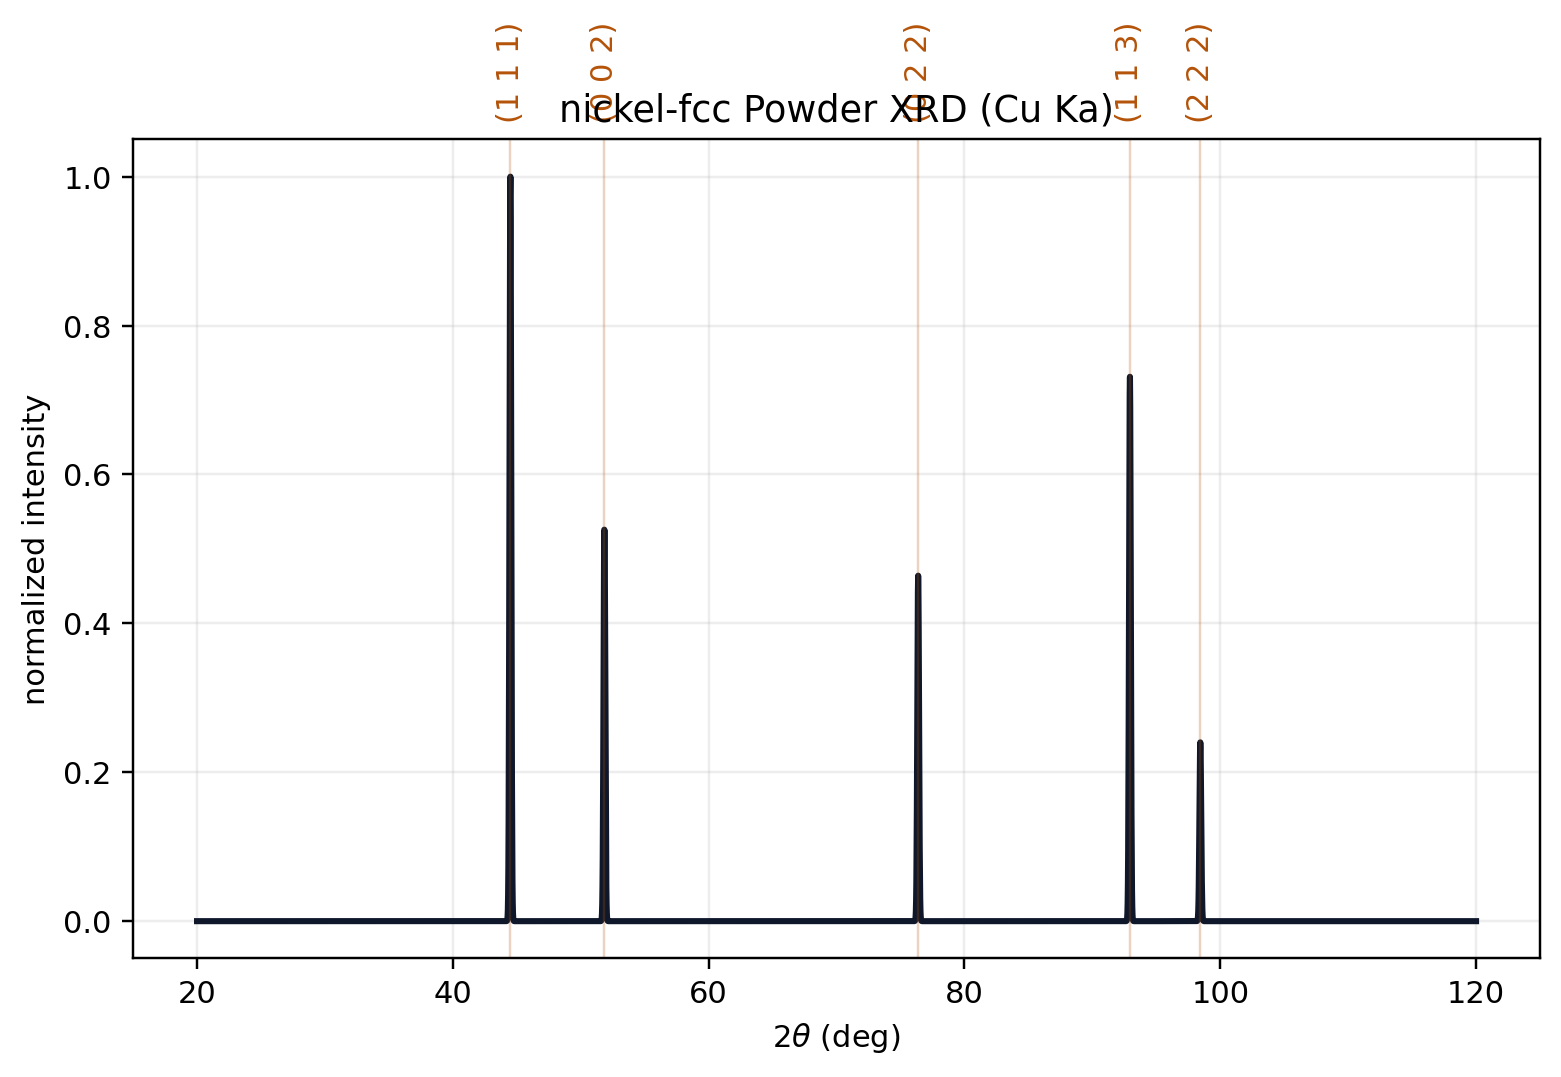

In [3]:
figure = plot_xrd_pattern(pattern, theme="journal")
figure


## Pedagogical Caveat

The current intensity model is structure-sensitive but still foundational. It uses
crystal multiplicity, a simple structure-factor proxy, and a Lorentz-polarization
factor rather than a full scattering-factor or instrument model.

The pinned validation case for this notebook checks peak positions and family
coverage against an external `pymatgen` reference artifact. Treat the rendered
intensity envelope as a teaching and prototyping surface, not as a calibrated
diffractometer model.
